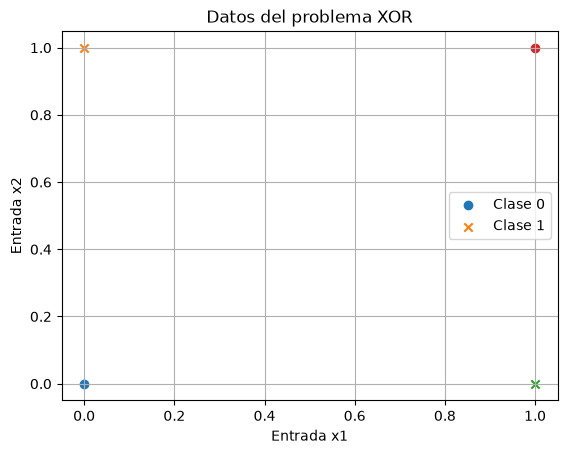

Época: 0 Error: 0.332182504663897
Época: 1000 Error: 0.05650081437632827
Época: 2000 Error: 0.0036905855238228017
Época: 3000 Error: 0.0015688080642976409
Época: 4000 Error: 0.000961512926039055
Época: 5000 Error: 0.000684013517445775
Época: 6000 Error: 0.0005272692107887482
Época: 7000 Error: 0.00042727915812859206
Época: 8000 Error: 0.000358247946568493
Época: 9000 Error: 0.0003078710182724831

Predicciones finales:
[[0.0142218 ]
 [0.99055716]
 [0.97896526]
 [0.0185573 ]]

Clases predichas:
[[0]
 [1]
 [1]
 [0]]

Comparación de resultados:
Entrada: [0 0]
Salida esperada: 0
Predicción: 0.014221796751927921
Clase predicha: 0
-----------------------------
Entrada: [0 1]
Salida esperada: 1
Predicción: 0.9905571624183505
Clase predicha: 1
-----------------------------
Entrada: [1 0]
Salida esperada: 1
Predicción: 0.9789652648566044
Clase predicha: 1
-----------------------------
Entrada: [1 1]
Salida esperada: 0
Predicción: 0.018557304313178168
Clase predicha: 0
---------------------------

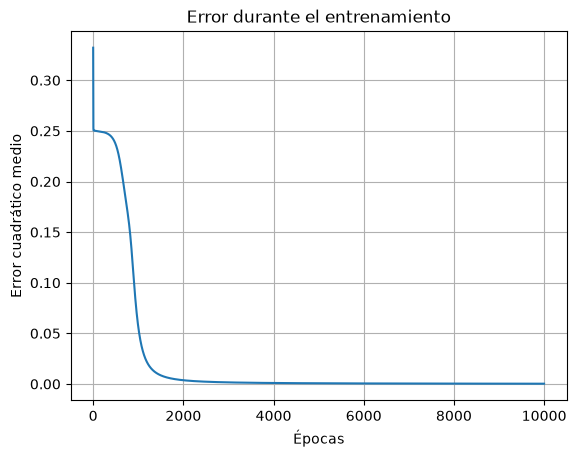

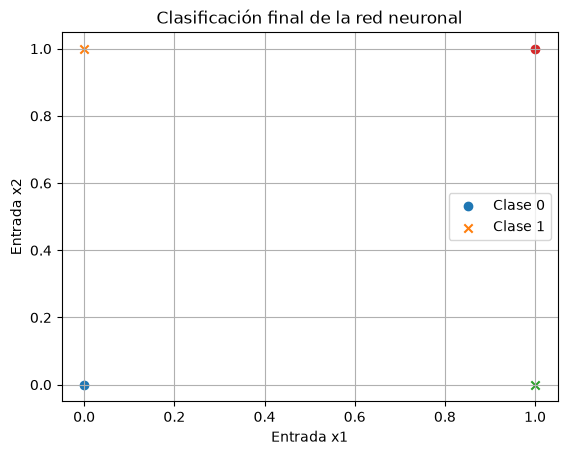

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([
    [0],
    [1],
    [1],
    [0]
])


for i in range(len(X)):

    if y[i] == 0:
        plt.scatter(
            X[i, 0],
            X[i, 1],
            marker='o',
            label='Clase 0' if i == 0 else ""
        )

    else:
        plt.scatter(
            X[i, 0],
            X[i, 1],
            marker='x',
            label='Clase 1' if i == 1 else ""
        )

plt.title("Datos del problema XOR")
plt.xlabel("Entrada x1")
plt.ylabel("Entrada x2")
plt.legend()
plt.grid(True)
plt.show()

def sigmoide(x):
    return 1 / (1 + np.exp(-x))


# Derivada de la sigmoide
def derivada_sigmoide(x):
    return x * (1 - x)


np.random.seed(42)

neuronas_entrada = 2
neuronas_ocultas = 4
neuronas_salida = 1


# Pesos y sesgos
W1 = np.random.uniform(
    size=(neuronas_entrada, neuronas_ocultas)
)

b1 = np.random.uniform(
    size=(1, neuronas_ocultas)
)

W2 = np.random.uniform(
    size=(neuronas_ocultas, neuronas_salida)
)

b2 = np.random.uniform(
    size=(1, neuronas_salida)
)


def propagacion_adelante(X, W1, b1, W2, b2):

    # Capa oculta
    Z1 = np.dot(X, W1) + b1
    A1 = sigmoide(Z1)

    # Capa de salida
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoide(Z2)

    return Z1, A1, Z2, A2



def calcular_error(y_real, y_predicha):

    return np.mean(
        (y_real - y_predicha) ** 2
    )


def clasificar(prediccion):

    if prediccion >= 0.5:
        return 1
    else:
        return 0



def entrenar_red(
    X,
    y,
    W1,
    b1,
    W2,
    b2,
    tasa_aprendizaje,
    epocas
):

    errores = []

    for epoca in range(epocas):


        Z1, A1, Z2, A2 = propagacion_adelante(
            X, W1, b1, W2, b2
        )


        error = y - A2


        # Error cuadrático medio
        error_promedio = calcular_error(
            y,
            A2
        )

        errores.append(error_promedio)

        ajuste_salida = (
            error *
            derivada_sigmoide(A2)
        )


        error_oculto = np.dot(
            ajuste_salida,
            W2.T
        )


        ajuste_oculto = (
            error_oculto *
            derivada_sigmoide(A1)
        )



        W2 = W2 + (
            np.dot(A1.T, ajuste_salida)
            * tasa_aprendizaje
        )

        b2 = b2 + (
            np.sum(
                ajuste_salida,
                axis=0,
                keepdims=True
            )
            * tasa_aprendizaje
        )


        W1 = W1 + (
            np.dot(X.T, ajuste_oculto)
            * tasa_aprendizaje
        )

        b1 = b1 + (
            np.sum(
                ajuste_oculto,
                axis=0,
                keepdims=True
            )
            * tasa_aprendizaje
        )


        if epoca % 1000 == 0:

            print(
                "Época:",
                epoca,
                "Error:",
                error_promedio
            )


    return W1, b1, W2, b2, errores


tasa_aprendizaje = 0.5
epocas = 10000

W1, b1, W2, b2, errores = entrenar_red(
    X,
    y,
    W1,
    b1,
    W2,
    b2,
    tasa_aprendizaje,
    epocas
)


Z1, A1, Z2, predicciones = propagacion_adelante(
    X,
    W1,
    b1,
    W2,
    b2
)


print("\nPredicciones finales:")
print(predicciones)


clases_predichas = []

for prediccion in predicciones:

    clase = clasificar(
        prediccion[0]
    )

    clases_predichas.append(clase)


clases_predichas = np.array(
    clases_predichas
).reshape(-1, 1)


print("\nClases predichas:")
print(clases_predichas)


print("\nComparación de resultados:")

for i in range(len(X)):

    print("Entrada:", X[i])
    print("Salida esperada:", y[i][0])
    print("Predicción:", predicciones[i][0])
    print("Clase predicha:", clases_predichas[i][0])
    print("-----------------------------")



aciertos = np.sum(
    clases_predichas == y
)

exactitud = aciertos / len(y)


print("\nExactitud del modelo:", exactitud)



plt.plot(errores)

plt.title("Error durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Error cuadrático medio")

plt.grid(True)
plt.show()


for i in range(len(X)):

    if clases_predichas[i] == 0:

        plt.scatter(
            X[i, 0],
            X[i, 1],
            marker='o',
            label='Clase 0' if i == 0 else ""
        )

    else:

        plt.scatter(
            X[i, 0],
            X[i, 1],
            marker='x',
            label='Clase 1' if i == 1 else ""
        )


plt.title("Clasificación final de la red neuronal")
plt.xlabel("Entrada x1")
plt.ylabel("Entrada x2")
plt.legend()
plt.grid(True)
plt.show()